This code is used to run a stock driven model for the smelter capacity to calculate direct GHG emissions for multiply data points of lifetime & retrofitting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from dynamic_stock_model import DynamicStockModel

Importing data of reference demand scenario first.

In [2]:
#Lifetime 40 (13 std dev) vs. 50 (17 std.dev.) years
lifetime_smelter = 50
std_dev_smelter = lifetime_smelter*0.33

#high demand (_high demand) vs. reference (0, because basic scenario) vs. "_Highest improvement"
Demand_scenario= ''

#here, it can be changed if we read the primary produciton without  ("S-") or with improved sorting and recycling technologies ("S+")
'_S+'
scrap_scenario = '_S-'

#smelter lifetime
LD = str(lifetime_smelter) + Demand_scenario + scrap_scenario

In [3]:
file = "Technology stocks/Smelter/Capacity data python" + Demand_scenario + scrap_scenario + ".xlsx"
data = pd.read_excel(file, sheet_name = 'Technologies_PB_' +str(lifetime_smelter), usecols='A:BP', skiprows=1, nrows=151)
#Input data (smelter capacity stocks) stays the same
data.reset_index(drop=True, inplace=True)
data.fillna(0, inplace=True)
data

,year,Primary Al (model) [kt],Mean value utilisation rate (reg)\n(based on geniSim and USGS),Smelter Capacity Stock (total),share Prebake (IAI),share Soderberg (IAI),Total inflows smelter,Total outflows smelter,Inflow-share PB,Inflow-share SS,...,GHG-emissions indirect (S1) [Mt],GHG-emissions indirect (S2) [Mt],"GHG-emissions indirect (BAU, ef.const.) [Mt]","GHG-emissions indirect (BAU, ef.red.) [Mt]","GHG-emissions indirect (S1, ef.const.) [Mt]","GHG-emissions indirect (S2, ef.const.) [Mt]",Retrofit BAT.2,Stock share new BAT.2,Energy demand mean BAT.2,Energy demand smelter BAT.2
0,1900,0.000000,0.87,0.000000,0.631835,0.368165,0.000000,0.000000,1.00,0.00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
1,1901,0.183590,0.87,0.211023,0.631835,0.368165,0.211368,0.000346,1.00,0.00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
2,1902,0.218913,0.87,0.251624,0.631835,0.368165,0.040739,0.000138,1.00,0.00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
3,1903,0.260710,0.87,0.299667,0.631835,0.368165,0.048220,0.000177,1.00,0.00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
4,1904,0.310180,0.87,0.356529,0.631835,0.368165,0.057088,0.000226,1.00,0.00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,2046,93897.801183,0.90,104330.890203,0.000000,0.000000,1732.342757,1519.770830,0.98,0.02,...,189.058991,187.094719,774.033725,193.305345,757.030463,749.165124,0.0,12.039478,0.0,0.0
147,2047,94048.455994,0.90,104498.284438,0.000000,0.000000,1740.149384,1572.755149,0.98,0.02,...,167.055429,165.116591,774.057602,170.974912,756.312862,747.535127,0.0,11.994497,0.0,0.0
148,2048,94164.784244,0.90,104627.538048,0.000000,0.000000,1754.508462,1625.254852,0.98,0.02,...,145.040010,143.167606,773.805705,148.590145,755.317839,745.567012,0.0,11.948693,0.0,0.0
149,2049,94253.883963,0.90,104726.537736,0.000000,0.000000,1776.016254,1677.016567,0.98,0.02,...,123.045690,121.285178,773.335545,126.184303,754.100185,743.310674,0.0,11.901907,0.0,0.0


In [4]:
file = "Technology stocks/Smelter/Capacity data python" + Demand_scenario + scrap_scenario + ".xlsx"
data_parameter = pd.read_excel(file, sheet_name = 'Tech.Parameter', usecols='A:O', nrows=151)
#Input data (smelter capacity stocks) stays the same
data_parameter.reset_index(drop=True, inplace=True)
data_parameter.fillna(0, inplace=True)
data_parameter

,year,Inflow-share PB,Inflow-share SS,Inflow-share Inert Anodes?,comment,Stock share PB (IAI,Stock share SS (IAI,Unnamed: 7,global Al production (USGS) [kt],Mean PFC intensity [t CO2/tAl],Direct emissions Anode consumption [t CO2/tAl],BAT energy demand (S1) [kWh/kg],BAT energy demand (S2) [kWh/kg],BAT energy demand (BAU) [kWh/kg],GHG [kt CO2e/GWh] for smelter electr. Mix
0,1900,1.00,0.00,0.0,0,1.0,0.0,0.0,6.8,0.000000,0.0,33.047161,33.047161,33.047161,0.000000
1,1901,1.00,0.00,0.0,0,1.0,0.0,0.0,6.8,0.000000,0.0,33.047161,33.047161,33.047161,0.000000
2,1902,1.00,0.00,0.0,0,1.0,0.0,0.0,7.9,0.000000,0.0,33.047161,33.047161,33.047161,0.000000
3,1903,1.00,0.00,0.0,0,1.0,0.0,0.0,8.5,0.000000,0.0,33.047161,33.047161,33.047161,0.000000
4,1904,1.00,0.00,0.0,0,1.0,0.0,0.0,10.0,0.000000,0.0,33.047161,33.047161,33.047161,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,2046,0.98,0.02,0.0,0,0.0,0.0,0.0,0.0,0.158065,1.4,12.140000,11.228000,12.959195,0.151605
147,2047,0.98,0.02,0.0,0,0.0,0.0,0.0,0.0,0.143548,1.4,12.140000,11.171000,12.959195,0.134088
148,2048,0.98,0.02,0.0,0,0.0,0.0,0.0,0.0,0.129032,1.4,12.140000,11.114000,12.959195,0.116571
149,2049,0.98,0.02,0.0,0,0.0,0.0,0.0,0.0,0.114516,1.4,12.140000,11.057000,12.959195,0.099053


In [5]:
parameters={"stock_smelter_t": np.array(data['Smelter Capacity Stock (total)']),
            "Lifetime_smelter": np.int,
            "Inflow_share_PB": np.array(data["Inflow-share PB"]),
            "Inflow_share_SS": np.array(data["Inflow-share SS"]),
            "MPR": np.array(data["Inflow-share IA in PB - S1"], dtype=float),
            "RF": np.array(data["Retrofit Sx.1"]),
            "e_PFC_mean": np.array(data_parameter['Mean PFC intensity [t CO2/tAl]']),
            "e_anode_consumption": np.array(data_parameter['Direct emissions Anode consumption [t CO2/tAl]'])
                    }

C:\Users\Morit\AppData\Local\Temp/ipykernel_23812/2873021806.py:2: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  "Lifetime_smelter": np.int,


## Smelter class

In [6]:
#a class to have all the functions and calculations together to calculate direct GHG emissions
class smelter:
    def __init__(self, scenario_name:str, IA_start:int, IA_MPR:float, IA_RF:int, lt_smelter:int):
        #arguments
            #IA_start: starting year of inert anodes (2030)
            #IA_MPR: market penetration rate which will be reached in the starting year (will be kept constant afterwards for the contour figures)
            #IA_RF: retrofitting rate in Mt annual capacity/yr
        
        self.scenario_name=scenario_name
        self.time_t=data.year
        self.parameters=parameters
        self.IA_MPR=IA_MPR
        self.IA_MPR_t=parameters["MPR"]
        self.IA_RF_t=parameters["RF"]
        self.IA_RF=IA_RF
        self.lt_smelter=lt_smelter
        self.IA_start=IA_start

    #now defining all the functions

    def compute_DSM_total(self):
        DSM_smelter = DynamicStockModel(t=self.time_t,
                         s=self.parameters["stock_smelter_t"],
                         lt={'Type': 'Normal', 
                             'Mean': np.array([self.lt_smelter]),
                             'StdDev': np.array([std_dev_smelter]) 
                             }
                            )
        DSM_smelter.compute_stock_driven_model() 
        DSM_smelter.compute_outflow_total()
        self.inflows_total_t=DSM_smelter.i
        self.outflows_total_t=DSM_smelter.o
        self.stock_tc=DSM_smelter.s_c


    def compute_DSM_PB(self):

        s_c_PB = self.stock_tc*self.parameters["Inflow_share_PB"]
        s_c_SS = self.stock_tc*self.parameters["Inflow_share_SS"]
        self.stock_PB_t=np.sum(s_c_PB, axis=1)
        self.stock_SS_t=np.sum(s_c_SS, axis=1)

        DSM_PB = DynamicStockModel(t=self.time_t,
                         s=self.stock_PB_t,
                         lt={'Type': 'Normal', 
                             'Mean': np.array([self.lt_smelter]),
                             'StdDev': np.array([std_dev_smelter]) 
                             }
                            )

        DSM_PB.compute_stock_driven_model()
        DSM_PB.compute_outflow_total()
        self.inflows_PB_t=DSM_PB.i

    
        self.stock_PB_tc= DSM_PB.s_c


    def technology_penetration_share (self):
        #defining Market penetration rate MPR
        self.IA_MPR_t[:]=0
        i=len(self.IA_MPR_t)-(2050-self.IA_start)-1
        self.IA_MPR_t[i:]=self.IA_MPR

    def technology_retrofit(self):
        #defining retrofitting rate
        self.IA_RF_t[:]=0
        i=len(self.IA_RF_t)-(2050-self.IA_start)-1
        self.IA_RF_t[i:]=self.IA_RF

    def compute_technology_stock_share(self):
        #compute stock cohort matrix for IA smelter
        self.stock_IA_tc=self.stock_PB_tc*self.IA_MPR_t
        
        #compute stock of IA smelter
        p_stock_new_before_retrofit = np.sum(self.stock_IA_tc, axis=1)

        #compute stock share of IAs without/before retrofitting
        self.p_stock_share_new_before_retrofit = np.divide(p_stock_new_before_retrofit, data['Smelter Capacity Stock (total)'])

        #compute retrofitting and stock share of IAs after retrofitting
        p_cumulative_retrofit = np.cumsum(self.IA_RF_t)
        self.p_stock_share_new_total = np.add(self.p_stock_share_new_before_retrofit, (np.divide(p_cumulative_retrofit, data['Smelter Capacity Stock (total)'])))
        self.p_stock_share_new_total=np.minimum(self.p_stock_share_new_total,1)
        self.stock_share_IA_t = self.p_stock_share_new_total
        self.stock_share_nonIA_t=1-self.stock_share_IA_t
        
        #compute stock of IA
        self.stock_IA_t= np.add(p_stock_new_before_retrofit, p_cumulative_retrofit)
    
    
    
    def compute_direct_GHG(self):
        #computing direct emissions from 2020 to 2050

        #Direct emissions Anode consumption =1.4 tCO2/tAl (ref. )
        #Direct emissions today PFC=0.55 (modern plant 0.1) tCO2/tAl (ref. IAI)
        #unit=[tCO2/tAl]
        direct_e_specific_nonIA_t= np.add(self.parameters['e_PFC_mean'], self.parameters['e_anode_consumption'])

        #calculate direct emissions in Mt CO2 per year
        self.direct_GHG_t=np.multiply(data['Primary Al (model) [kt]'], np.multiply(direct_e_specific_nonIA_t, self.stock_share_nonIA_t)) / 1000
        self.direct_GHG_specific_t=np.divide(self.direct_GHG_t, data['Primary Al (model) [kt]'])*1000
        
    def run_all(self):
        self.compute_DSM_total()
        self.compute_DSM_PB()
        self.technology_penetration_share()
        self.technology_retrofit()
        self.compute_technology_stock_share()
        self.compute_direct_GHG()

### Running model

In [7]:
highResolution=True
if highResolution==True:
    #defining the lifetimes and retrofitting
    lifetimes=np.linspace(20,70, 401)
    #market penetration rate: MPR
    mpr=np.linspace(0,1, 201)
    #mpr=np.array([1.0])
if highResolution==False:
    #defining the lifetimes and retrofitting
    lifetimes=np.linspace(20,70, 51)
    #market penetration rate: MPR
    mpr=np.linspace(0,1, 11)
    #mpr=np.array([1.0])

In [8]:
#setting up dataframe for the reults
#colums: lifetimes 
#rows: market penetration rate (constant from 2030 onwards)
results_refdemand_noRF=pd.DataFrame(columns=mpr, index=lifetimes.tolist())
results_refdemand_2000RF=pd.DataFrame(columns=mpr, index=lifetimes.tolist())
results_highdemand_noRF=pd.DataFrame(columns=mpr, index=lifetimes.tolist())
results_highdemand_2000RF=pd.DataFrame(columns=mpr, index=lifetimes.tolist())

pd.options.display.float_format = "{:,.2f}".format

v = np.linspace (0, 1.5 , 26)


#### reference demand (with scrap surplus)

Here we run the model for the reference demand scenarios, where a scrap surplus occurs (no advanced sorting and recycling technologies available)

##### Reference demand - No retrofitting

First, we run it for no retrofitting

In [9]:
#running model for no retrofitting
retrofitting=0
    
for l in lifetimes:
    thislifetime=np.array([])
    for m in mpr:
        smelter_test=smelter(scenario_name="test", IA_start=2030, IA_MPR=m, IA_RF=retrofitting, lt_smelter=l)
        smelter_test.run_all()
        thislifetime=np.append(thislifetime, smelter_test.direct_GHG_specific_t[150])
        #print(f'Specific direct GHG in 2050 for lifetime of {l} years, retrofitting of {retrofitting} Mt/yr and MPR of {m:.2f} is: {smelter_test.direct_GHG_specific_t[150]:.2f}')
    results_refdemand_noRF.loc[l]=thislifetime

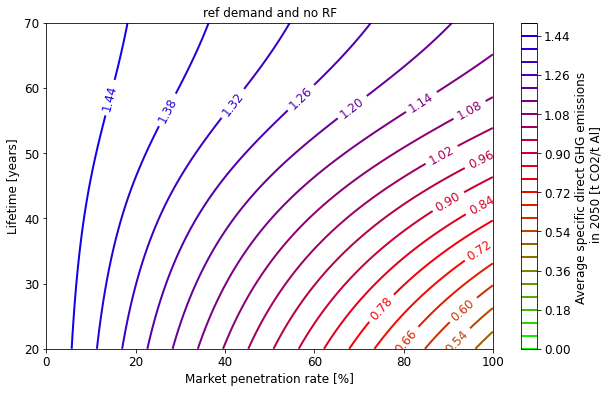

In [10]:
#plotting contour for ref demand and no RF
X = results_refdemand_noRF.columns.values*100
Y = results_refdemand_noRF.index.values
Z = results_refdemand_noRF.values

fig=plt.figure(figsize = (10,6))
contour=plt.contour(X, Y, Z, 20, cmap='brg_r', linewidths=2, levels=v)
# Add labels and colorbar
plt.xlabel('Market penetration rate [%]', fontsize=12)
plt.xticks(fontsize=12)
plt.ylabel('Lifetime [years]', fontsize=12)
plt.yticks(fontsize=12)
cbar=plt.colorbar()
cbar.set_label('Average specific direct GHG emissions \n in 2050 [t CO2/t Al]', fontsize=12)
cbar.ax.tick_params(labelsize=12)
plt.clabel(contour, inline=True, fontsize=12)
plt.title("ref demand and no RF")

plt.show()

##### Reference demand - 2000 Mt/yr retrofitting

Then, we run it for 2000 Mt annual retrofitting

In [11]:
#running model for reference demand and 2000 Mt/yr retrofitting
retrofitting=2000
    
for l in lifetimes:
    thislifetime=np.array([])
    for m in mpr:
        smelter_test=smelter(scenario_name="test", IA_start=2030, IA_MPR=m, IA_RF=retrofitting, lt_smelter=l)
        smelter_test.run_all()
        thislifetime=np.append(thislifetime, smelter_test.direct_GHG_specific_t[150])
        #print(f'Specific direct GHG in 2050 for lifetime of {l} years, retrofitting of {retrofitting} Mt/yr and MPR of {m:.2f} is: {smelter_test.direct_GHG_specific_t[150]:.2f}')
    results_refdemand_2000RF.loc[l]=thislifetime

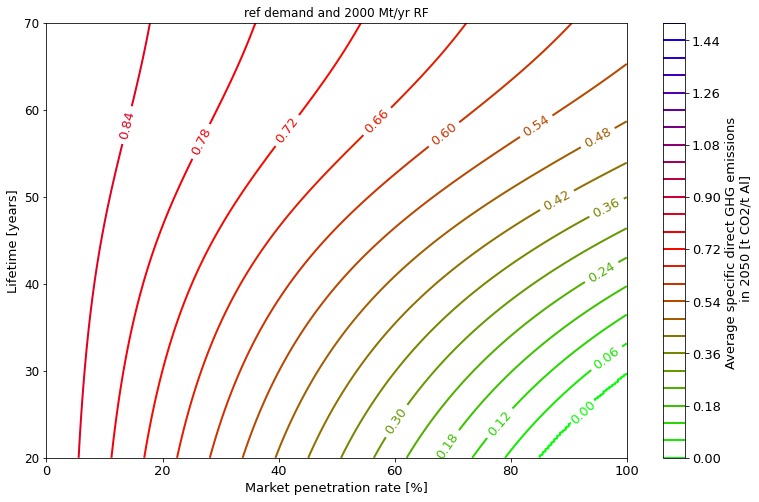

In [12]:
#plotting contour for ref demand and 2000 Mt/yr RF
X = results_refdemand_2000RF.columns.values*100
Y = results_refdemand_2000RF.index.values
Z = results_refdemand_2000RF.values

fig=plt.figure(figsize = (13,8))

contour=plt.contour(X, Y, Z, 20, cmap='brg_r', linewidths=2, levels=v)
# Add labels and colorbar
plt.xlabel('Market penetration rate [%]', fontsize=13)
plt.xticks(fontsize=13)
plt.ylabel('Lifetime [years]', fontsize=13)
plt.yticks(fontsize=12)
cbar=plt.colorbar()
cbar.set_label('Average specific direct GHG emissions \n in 2050 [t CO2/t Al]', fontsize=13)
cbar.ax.tick_params(labelsize=13)
plt.clabel(contour, inline=True, fontsize=13)
plt.title("ref demand and 2000 Mt/yr RF")

plt.show()

#### high demand (with scrap surplus)

Here we run the model for the high demand scenarios, where a scrap surplus occurs (no advanced sorting and recycling technologies available). 
For this, we need to import a new data file that includes the primary smelter capacity for high demand.

In [13]:
#setting up data

#Lifetime 40 (13 std dev) vs. 50 (17 std.dev.) years
lifetime_smelter = 40
std_dev_smelter = lifetime_smelter*0.33

#high demand (_high demand) vs. reference (0, because basic scenario) vs. "_Highest improvement"
Demand_scenario= '_high demand'

'_S+'
scrap_scenario = '_S-'

#smelter lifetime
LD = str(lifetime_smelter) + Demand_scenario + scrap_scenario

file = "Technology stocks/Smelter/Capacity data python" + Demand_scenario + scrap_scenario + ".xlsx"
data = pd.read_excel(file, sheet_name = 'Technologies_PB_' +str(lifetime_smelter), usecols='A:BP', skiprows=1, nrows=151)
#Input data (smelter capacity stocks) stays the same
data.reset_index(drop=True, inplace=True)
data.fillna(0, inplace=True)

In [14]:
parameters={"stock_smelter_t": np.array(data['Smelter Capacity Stock (total)']),
            "Lifetime_smelter": np.int,
            "Inflow_share_PB": np.array(data["Inflow-share PB"]),
            "Inflow_share_SS": np.array(data["Inflow-share SS"]),
            "MPR": np.array(data["Inflow-share IA in PB - S1"], dtype=float),
            "RF": np.array(data["Retrofit Sx.1"]),
            "e_PFC_mean": np.array(data_parameter['Mean PFC intensity [t CO2/tAl]']),
            "e_anode_consumption": np.array(data_parameter['Direct emissions Anode consumption [t CO2/tAl]'])
                    }

C:\Users\Morit\AppData\Local\Temp/ipykernel_23812/2873021806.py:2: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  "Lifetime_smelter": np.int,


##### High demand - No retrofitting

In [15]:
#running model for no retrofitting
retrofitting=0
    
for l in lifetimes:
    thislifetime=np.array([])
    for m in mpr:
        smelter_test=smelter(scenario_name="test", IA_start=2030, IA_MPR=m, IA_RF=retrofitting, lt_smelter=l)
        smelter_test.run_all()
        thislifetime=np.append(thislifetime, smelter_test.direct_GHG_specific_t[150])
        #print(f'Specific direct GHG in 2050 for lifetime of {l} years, retrofitting of {retrofitting} Mt/yr and MPR of {m:.2f} is: {smelter_test.direct_GHG_specific_t[150]:.2f}')
    results_highdemand_noRF.loc[l]=thislifetime

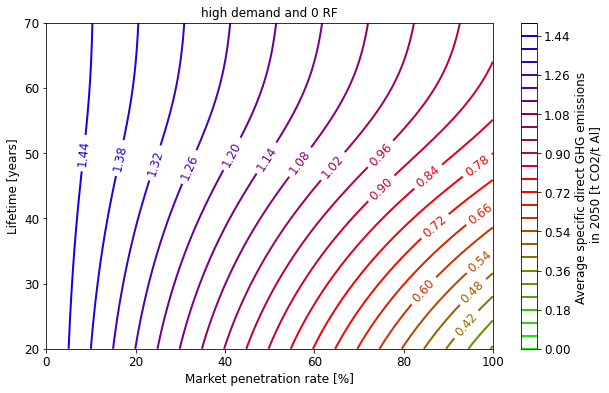

In [16]:
#plotting contour for high demand and no RF
X = results_highdemand_noRF.columns.values*100
Y = results_highdemand_noRF.index.values
Z = results_highdemand_noRF.values

fig=plt.figure(figsize = (10,6))
contour=plt.contour(X, Y, Z, 20, cmap='brg_r', linewidths=2, levels=v)
# Add labels and colorbar
plt.xlabel('Market penetration rate [%]', fontsize=12)
plt.xticks(fontsize=12)
plt.ylabel('Lifetime [years]', fontsize=12)
plt.yticks(fontsize=12)
cbar=plt.colorbar()
cbar.set_label('Average specific direct GHG emissions \n in 2050 [t CO2/t Al]', fontsize=12)
cbar.ax.tick_params(labelsize=12)
plt.clabel(contour, inline=True, fontsize=12)
plt.title("high demand and 0 RF")

plt.show()

##### High demand - 2000 Mt/yr retrofitting

In [17]:
#running model for high demand and 2000 Mt/yr retrofitting
retrofitting=2000
    
for l in lifetimes:
    thislifetime=np.array([])
    for m in mpr:
        smelter_test=smelter(scenario_name="test", IA_start=2030, IA_MPR=m, IA_RF=retrofitting, lt_smelter=l)
        smelter_test.run_all()
        thislifetime=np.append(thislifetime, smelter_test.direct_GHG_specific_t[150])
        #print(f'Specific direct GHG in 2050 for lifetime of {l} years, retrofitting of {retrofitting} Mt/yr and MPR of {m:.2f} is: {smelter_test.direct_GHG_specific_t[150]:.2f}')
    results_highdemand_2000RF.loc[l]=thislifetime

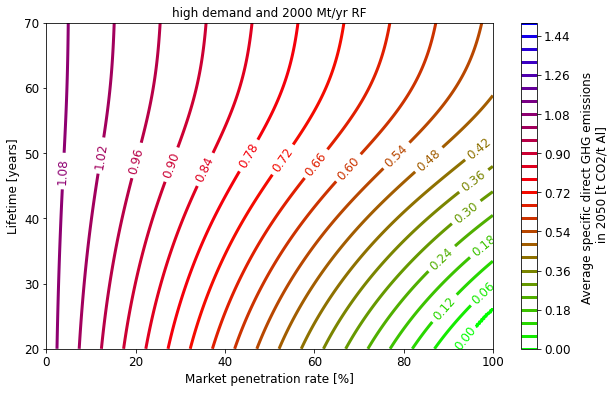

In [18]:
#plotting contour for high demand and 2000 Mt/yr RF
X = results_highdemand_2000RF.columns.values*100
Y = results_highdemand_2000RF.index.values
Z = results_highdemand_2000RF.values

fig=plt.figure(figsize = (10,6))
contour=plt.contour(X, Y, Z, 20, cmap='brg_r', linewidths=3, levels=v)
# Add labels and colorbar
plt.xlabel('Market penetration rate [%]', fontsize=12)
plt.xticks(fontsize=12)
plt.ylabel('Lifetime [years]', fontsize=12)
plt.yticks(fontsize=12)
cbar=plt.colorbar()
cbar.set_label('Average specific direct GHG emissions \n in 2050 [t CO2/t Al]', fontsize=12, labelpad=10)
cbar.ax.tick_params(labelsize=12)
plt.clabel(contour, inline=True, fontsize=12)
plt.title("high demand and 2000 Mt/yr RF")


plt.savefig(('Python exports/Contours L MPR for high demand and 2000 RF inclusive colormap'), dpi=900)

In [19]:
#saving the dataframes
pd.DataFrame(results_refdemand_noRF).to_excel('Python exports/L-MPR_refdemand_noRF.xlsx')
pd.DataFrame(results_refdemand_2000RF).to_excel('Python exports/L-MPR_refdemand_2000RF.xlsx')
pd.DataFrame(results_highdemand_noRF).to_excel('Python exports/L-MPR_highdemand_noRF.xlsx')
pd.DataFrame(results_highdemand_2000RF).to_excel('Python exports/L-MPR_highdemand_2000RF.xlsx')

### Plotting the 4 contour plots

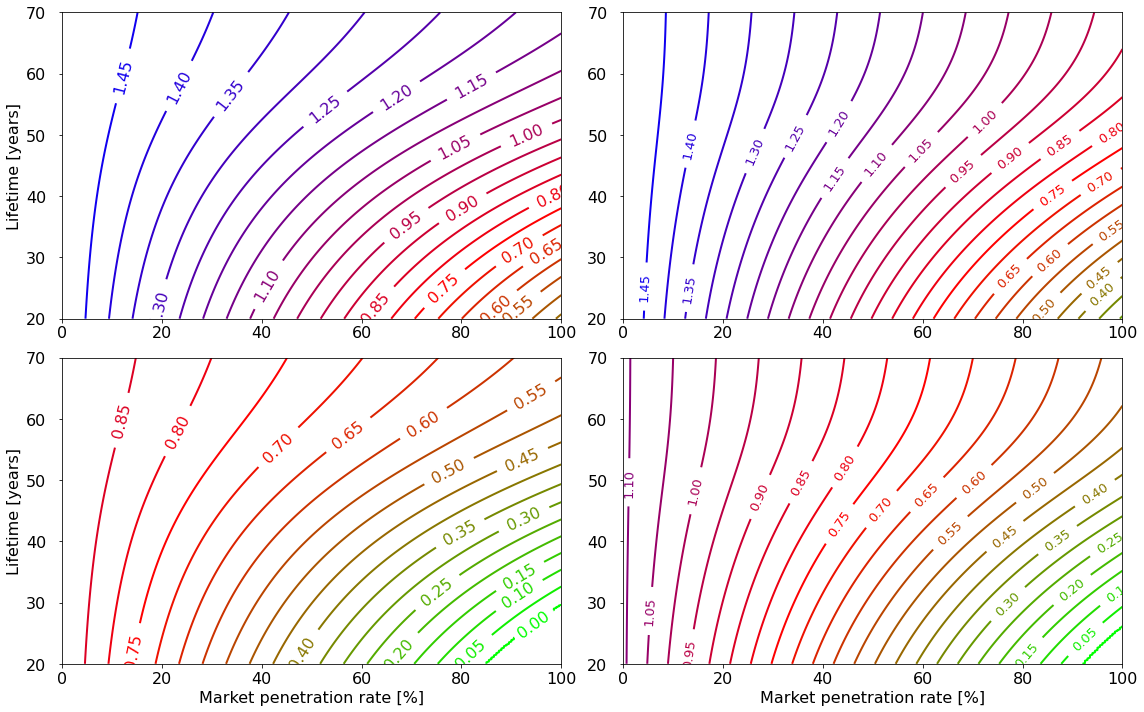

In [20]:
titels=False
fig, axs = plt.subplots(2, 2, figsize=(16,10))

#setting the same levels/range for all plots
v = np.linspace (0, 1.5 , 31)

#ref demand and no Mt/yr RF
X1 = results_refdemand_noRF.columns.values*100
Y1 = results_refdemand_noRF.index.values
Z1 = results_refdemand_noRF.values
contour1=axs[0,0].contour(X1, Y1, Z1, 20, cmap='brg_r', linewidths=2, levels=v)
#axs[0,0].set_xlabel('Market penetration rate [%]', fontsize=13)
axs[0,0].set_ylabel('Lifetime [years]', fontsize=16)
#axs[0,0].clabel(contour, inline=True, fontsize=13)
axs[0,0].tick_params(axis='x', labelsize=16)
axs[0,0].tick_params(axis='y', labelsize=16, pad=12)
if titels==True:
    axs[0,0].set_title('reference demand, no RF')
axs[0,0].clabel(contour1, inline=True, fontsize=16)


#ref demand and 2000 Mt/yr RF
X2 = results_refdemand_2000RF.columns.values*100
Y2 = results_refdemand_2000RF.index.values
Z2 = results_refdemand_2000RF.values
contour2=axs[1,0].contour(X2, Y2, Z2, 20, cmap='brg_r', linewidths=2, levels=v)
axs[1,0].set_xlabel('Market penetration rate [%]', fontsize=16)
axs[1,0].tick_params(axis='x', labelsize=16)
axs[1,0].set_ylabel('Lifetime [years]', fontsize=16)
axs[1,0].tick_params(axis='y', labelsize=16, pad=12)
if titels==True:
    axs[1,0].set_title('reference demand, 2000 Mt/yr RF')
axs[1,0].clabel(contour2, inline=True, fontsize=16)

#high demand and no Mt/yr RF
X3 = results_highdemand_noRF.columns.values*100
Y3 = results_highdemand_noRF.index.values
Z3 = results_highdemand_noRF.values
contour3=axs[0,1].contour(X3, Y3, Z3, 20, cmap='brg_r', linewidths=2, levels=v)
#axs[0,1].set_xlabel('Market penetration rate [%]', fontsize=13)
#axs[0,1].set_ylabel('Lifetime [years]', fontsize=13)
#axs[0,1].clabel(contour, inline=True, fontsize=13)
axs[0,1].tick_params(axis='x', labelsize=16)
axs[0,1].tick_params(axis='y', labelsize=16, pad=12)
if titels==True:
    axs[0,1].set_title('high demand, no RF')
axs[0,1].clabel(contour3, inline=True, fontsize=13)

#high demand and 2000 Mt/yr RF
X4 = results_highdemand_2000RF.columns.values*100
Y4 = results_highdemand_2000RF.index.values
Z4 = results_highdemand_2000RF.values
contour4=axs[1,1].contour(X4, Y4, Z4, 20, cmap='brg_r', linewidths=2, levels=v)
axs[1,1].set_xlabel('Market penetration rate [%]', fontsize=16)
axs[1,1].tick_params(axis='x', labelsize=16)
#axs[1,1].set_ylabel('Lifetime [years]', fontsize=13)
axs[1,1].tick_params(axis='y', labelsize=16, pad=12)
if titels==True:
    axs[1,1].set_title('high demand, 2000 Mt/yr RF')
axs[1,1].clabel(contour4, inline=True, fontsize=13)

#fig.colorbar(contour1, ax=[axs[0,1], axs[1,1]], pad=1)

fig.tight_layout()
plt.savefig(('Python exports/Contours L MPR for ref&high demand and no&2000 RF'), dpi=900)